# Lựa chọn dữ liệu Ảnh


In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

In [5]:
folder = r"C:\Users\Admin\Downloads\image"
file_names = ["img1.jpg", "img2.jpg", "img3.jpg", "img4.jpg",
              "img5.jpg", "img6.jpg", "img7.jpg", "img8.jpg"]
data = []
 

# Bài 1: Biểu diễn dữ liệu thành ma trận & độ tương đồng

## Ý 1: Biến dữ liệu thành ma trận.

Em đang có ma trận $\mathbf{X}$ là ma trận biểu diễn tạo thành từ một tập ma trận ảnh (8 ảnh). Với mỗi hàng thể hiện đặc trưng 1 **vector** cho mỗi ảnh, và mỗi cột thì thể hiện một đặc trưng pixel của một tấm ảnh tại 1 vị trí nào đó.

In [6]:
for name in file_names:
    path = os.path.join(folder, name)
    image = Image.open(path).convert("L").resize((64,64))
    M = np.array(image,dtype = float)
    v = M.flatten()
    data.append(v)
X = np.array(data)
print("Kích thước ma trận dữ liệu X:", X.shape)

Kích thước ma trận dữ liệu X: (8, 4096)


Vì ảnh đã resize về $64\times 64 $ nên sẽ có $4096$ pixel, và 8 ảnh nên sẽ có shape theo chiều $x$ là 8.

# Ý 2: Phép toán cơ bản. 

In [7]:
mean_vector = np.mean(X,axis=0)
print(f"Vector trung bình là {mean_vector}")
print("Shape của mean_vector:", mean_vector.shape)
X_centered = X - mean_vector
print("Shape của X sau khi trừ trung bình:", X_centered.shape)

Vector trung bình là [110.875 114.5   111.625 ... 122.75  127.125 119.625]
Shape của mean_vector: (4096,)
Shape của X sau khi trừ trung bình: (8, 4096)


# Ý 3: Cosine similarity

In [8]:
def cosine_similarity (X , Y = None ):
    if Y is None:
        Y = X
    Xn =  X/np.linalg.norm(X,axis=1,keepdims = True)
    Yn = Y/np.linalg.norm(Y,axis=1,keepdims=True)
    return Xn@Yn.T
S=cosine_similarity(X,X)
print(S.shape)
    

(8, 8)


# Ý 4: Truy vấn

In [9]:
def search(query, top_k=3):
    """Tìm top_k ảnh giống query nhất theo cosine similarity."""
    if query.ndim == 1:
        query = query.reshape(1, -1)

    scores = cosine_similarity(query, X).flatten()

    # Sắp xếp giảm dần; bỏ qua chính query (score = 1.0 nếu query thuộc X)
    sorted_idx = np.argsort(scores)[::-1]

    results = []
    for idx in sorted_idx:
        results.append((int(idx), float(scores[idx])))
        if len(results) == top_k:
            break
    return results

# Demo: tìm 3 ảnh giống ảnh số 0 nhất
print("Kết quả search cho ảnh 0 (top_k=3):")
for idx, score in search(X[0], top_k=3):
    print(f"  Ảnh {idx}: cosine = {score:.4f}")

Kết quả search cho ảnh 0 (top_k=3):
  Ảnh 0: cosine = 1.0000
  Ảnh 2: cosine = 1.0000
  Ảnh 7: cosine = 0.9609


# Ý 5: Nhận xét

In [10]:
import numpy as np

def analyze_pairs(S):
    # chỉ lấy nửa trên, bỏ đường chéo
    mask = np.triu(np.ones_like(S, dtype=bool), k=1)

    scores = S[mask]
    pairs = np.argwhere(mask)

    max_id = np.argmax(scores)
    min_id = np.argmin(scores)

    i_max, j_max = pairs[max_id]
    i_min, j_min = pairs[min_id]

    print("Cặp giống nhau nhất:")
    print(f"Ảnh {i_max} và ảnh {j_max}, cosine = {scores[max_id]:.4f}")

    print("\nCặp khác biệt nhất:")
    print(f"Ảnh {i_min} và ảnh {j_min}, cosine = {scores[min_id]:.4f}")

    return (i_max, j_max, scores[max_id]), (i_min, j_min, scores[min_id])


In [11]:
most_similar, most_different = analyze_pairs(S)

Cặp giống nhau nhất:
Ảnh 0 và ảnh 2, cosine = 1.0000

Cặp khác biệt nhất:
Ảnh 1 và ảnh 5, cosine = 0.7467


# Bài 2: Biến đổi tuyến tính & SVD (Lựa chọn A)


### Ý 1: Biến đổi tuyến tính

In [12]:
points = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1],
    [0, 0]  
])
theta = np.pi / 4   # quay 45 độ
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])
sx = 2.0   # co giãn theo trục x
sy = 0.5   # co giãn theo trục y

S = np.array([
    [sx, 0],
    [0, sy]
])
rotated_points = points @ R.T
scaled_points = points @ S.T
transformed_points = points @ S.T @ R.T

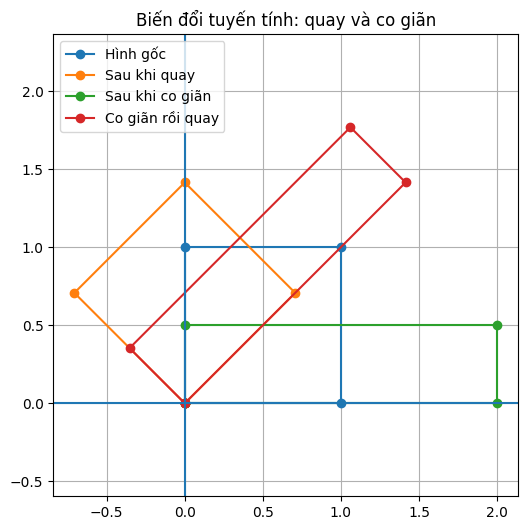

In [13]:
plt.figure(figsize=(6, 6))

plt.plot(points[:, 0], points[:, 1], 'o-', label="Hình gốc")
plt.plot(rotated_points[:, 0], rotated_points[:, 1], 'o-', label="Sau khi quay")
plt.plot(scaled_points[:, 0], scaled_points[:, 1], 'o-', label="Sau khi co giãn")
plt.plot(transformed_points[:, 0], transformed_points[:, 1], 'o-', label="Co giãn rồi quay")

plt.axhline(0)
plt.axvline(0)
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.title("Biến đổi tuyến tính: quay và co giãn")
plt.show()

### Ý 2,3,4

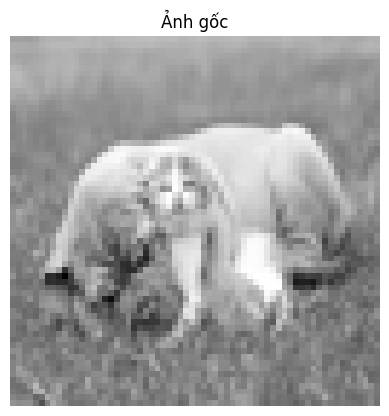

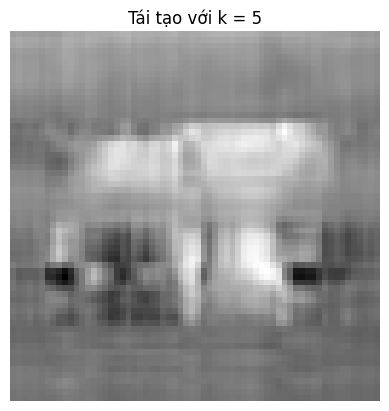

k = 5
Tỉ lệ nén = 0.1575
Sai số tái tạo = 0.0969



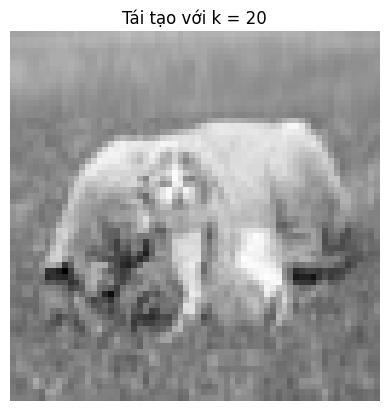

k = 20
Tỉ lệ nén = 0.6299
Sai số tái tạo = 0.0347



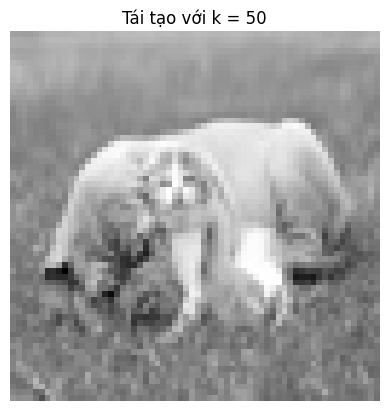

k = 50
Tỉ lệ nén = 1.5747
Sai số tái tạo = 0.0023



In [14]:
H, W = 64, 64
M = X[0].reshape(H, W)

# Phân rã SVD
U, S, Vt = np.linalg.svd(M, full_matrices=False)

def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

ks = [5, 20, 50]

plt.imshow(M, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")
plt.show()

errors = []
compression_rates = []

for k in ks:
    M_k = reconstruct(k)

    # Sai số tái tạo Frobenius tương đối
    error = np.linalg.norm(M - M_k, ord="fro") / np.linalg.norm(M, ord="fro")
    errors.append(error)

    # Số tham số sau nén: U_k + S_k + Vt_k
    compressed_params = k * (H + W + 1)
    original_params = H * W
    compression_rate = compressed_params / original_params
    compression_rates.append(compression_rate)

    plt.imshow(M_k, cmap="gray")
    plt.title(f"Tái tạo với k = {k}")
    plt.axis("off")
    plt.show()

    print(f"k = {k}")
    print(f"Tỉ lệ nén = {compression_rate:.4f}")
    print(f"Sai số tái tạo = {error:.4f}")
    print()

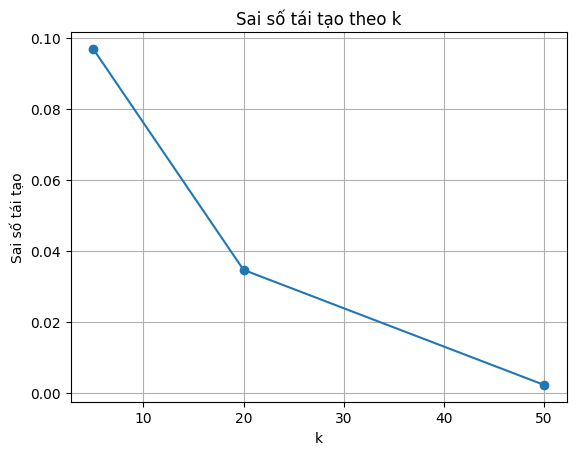

In [15]:
plt.plot(ks, errors, marker="o")
plt.xlabel("k")
plt.ylabel("Sai số tái tạo")
plt.title("Sai số tái tạo theo k")
plt.grid(True)
plt.show()

**Nhận xét**: Khi k nhỏ, ảnh được nén mạnh hơn nhưng mất nhiều chi tiết hơn. Khi k tăng, số giá trị kỳ dị được giữ lại nhiều hơn nên ảnh tái tạo rõ hơn và sai số giảm. Với $k=5$, ảnh thường chỉ giữ được cấu trúc chính. Với k = 20, ảnh đã dễ nhận ra hơn. Với $ k = 50$, ảnh gần giống ảnh gốc hơn nhưng tỉ lệ nén thấp hơn.

Kết quả này liên hệ với giảm chiều và nén dữ liệu trong AI: ta chỉ giữ lại các thành phần quan trọng nhất của dữ liệu, loại bỏ bớt phần ít đóng góp. Điều này giúp giảm số chiều, giảm dung lượng lưu trữ và có thể làm mô hình học hiệu quả hơn.